<a href="https://colab.research.google.com/github/sedefcoskun/EEG-Music-Impact-ML/blob/main/01_Data_Extraction_and_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Workspace Configuration & Environment Setup
To ensure secure and reproducible access to the data, cloud storage (Google Drive) integration has been established, and the primary working directory has been configured.

In [1]:
import os
from google.colab import drive

# Mount Google Drive to access my project workspace
drive.mount('/content/drive')

# WARNING: Change the path below to your own Google Drive folder if you are cloning this repo
# Define the path to my main project directory
project_folder = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN'

# Set the current working directory for the upcoming operations
os.chdir(project_folder)
print(f"Working directory successfully set to: {os.getcwd()}")

Mounted at /content/drive
Working directory successfully set to: /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN


### 2. Dependency Installation & Data Synchronization
Required Python libraries for signal processing (MNE), data manipulation (Pandas, NumPy), and machine learning (Scikit-Learn) are installed. Additionally, the AWS CLI is utilized to securely synchronize the raw EEG data from OpenNeuro directly into the project workspace.

In [2]:
# Install the necessary libraries for the EEG processing pipeline
!pip install mne pandas numpy scikit-learn awscli

import os

# Define the data directory
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'
os.makedirs(raw_bids_dir, exist_ok=True)

print("Initiating raw EEG data synchronization via AWS S3...")

# Utilizing AWS CLI for direct, fail-safe synchronization with OpenNeuro's Amazon S3 buckets
!aws s3 sync --no-sign-request s3://openneuro.org/ds003774 /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data

print("data synchronization completed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 4.6 MB/s eta 0:00:00
  Attempting uninstall: rsa
    Found existing installation: rsa 4.9.1
    Uninstalling rsa-4.9.1:
      Successfully uninstalled rsa-4.9.1
  Attempting uninstall: docutils
    Found existing installation: docutils 0.21.2
    Uninstalling docutils-0.21.2:
      Successfully uninstalled docutils-0.21.2
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of t

Initiating raw EEG data synchronization via AWS S3...
^C
data synchronization completed successfully.


### 3. Data Directory Structure Verification
The root directory is inspected to confirm the successful synchronization of the data and to verify that the folder hierarchy complies with the Brain Imaging Data Structure (BIDS) standards.

In [3]:
import os

# Path to the synced data
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'

# List all files and folders in the root directory to verify the structure
if os.path.exists(raw_bids_dir):
    print("--- Verifying Data Directory Structure ---")
    items = sorted(os.listdir(raw_bids_dir))
    for item in items:
        print(f"- {item}")
else:
    print("Error: Directory path not found. Check Google Drive mount or folder name.")

--- Verifying Data Directory Structure ---
- .datalad
- .gitattributes
- CHANGES
- Code
- README
- annex-uuid
- dataset_description.json
- sourcedata
- stimuli
- sub-001
- sub-002
- sub-003
- sub-004
- sub-005
- sub-006
- sub-007
- sub-008
- sub-009
- sub-010
- sub-011
- sub-012
- sub-013
- sub-014
- sub-015
- sub-016
- sub-017
- sub-018
- sub-019
- sub-020


### 4. BIDS Internal Structure: Subject Directory
Before processing, we must inspect the internal hierarchy of an individual subject's directory (e.g., `sub-001`) to ensure all required raw EEG data (`.set`) and event logs (`.tsv`) are correctly placed according to BIDS standards.

In [1]:
import os

# Define data path
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'
sub001_dir = os.path.join(raw_bids_dir, 'sub-001')

# Walk through sub-001 folder to see the exact file structure
if os.path.exists(sub001_dir):
    print("--- All files inside sub-001 ---")
    for root, dirs, files in os.walk(sub001_dir):
        for file in files:
            # Get the relative path from the data root
            rel_path = os.path.relpath(os.path.join(root, file), raw_bids_dir)
            print(rel_path)
else:
    print("sub-001 directory not found.")

--- All files inside sub-001 ---
sub-001/ses-12/eeg/sub-001_ses-12_task-MusicListening_run-12_eeg.set
sub-001/ses-12/eeg/sub-001_ses-12_task-MusicListening_run-12_coordsystem.json
sub-001/ses-12/eeg/sub-001_ses-12_task-MusicListening_run-12_eeg.json
sub-001/ses-12/eeg/sub-001_ses-12_task-MusicListening_run-12_events.tsv
sub-001/ses-12/eeg/sub-001_ses-12_task-MusicListening_run-12_events.json
sub-001/ses-12/eeg/sub-001_ses-12_task-MusicListening_run-12_channels.tsv
sub-001/ses-12/eeg/sub-001_ses-12_task-MusicListening_run-12_electrodes.tsv
sub-001/ses-11/eeg/sub-001_ses-11_task-MusicListening_run-11_eeg.set
sub-001/ses-11/eeg/sub-001_ses-11_task-MusicListening_run-11_channels.tsv
sub-001/ses-11/eeg/sub-001_ses-11_task-MusicListening_run-11_eeg.json
sub-001/ses-11/eeg/sub-001_ses-11_task-MusicListening_run-11_coordsystem.json
sub-001/ses-11/eeg/sub-001_ses-11_task-MusicListening_run-11_electrodes.tsv
sub-001/ses-11/eeg/sub-001_ses-11_task-MusicListening_run-11_events.tsv
sub-001/ses-11/e

### 5. Hardware Metadata & Electrode Architecture
To accurately process the EEG signals, we extract the hardware specifications (`eeg.json`), active channel lists (`channels.tsv`), and the 3D spatial coordinates of the sensors (`electrodes.tsv`). This confirms our sampling rate (250 Hz) and the 129-channel high-density cap configuration.

In [2]:
import pandas as pd
import json
import glob
import os

# Define data path
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'

# DISPLAY EEG CHANNEL CONTENT
print("=== EEG CHANNELS DATA (channels.tsv) ===\n")

# Find the first channels.tsv file for subject 1
channels_files = sorted(glob.glob(os.path.join(raw_bids_dir, 'sub-001', '**', '*channels.tsv'), recursive=True))

if channels_files:
    first_channel_file = channels_files[0]
    print(f"Loading file: {os.path.basename(first_channel_file)}\n")

    # Read and display the raw content
    df_channels = pd.read_csv(first_channel_file, sep='\t')
    print(df_channels.head(15)) # Showing first 15 channels
    print(f"\nTotal Channels in file: {len(df_channels)}")
    print("\n" + "="*50 + "\n")

# DISPLAY EEG METADATA CONTENT
print("=== EEG HARDWARE METADATA (eeg.json) ===\n")

# Find the first eeg.json file for subject 1
json_files = sorted(glob.glob(os.path.join(raw_bids_dir, 'sub-001', '**', '*eeg.json'), recursive=True))

if json_files:
    first_json_file = json_files[0]
    print(f"Loading file: {os.path.basename(first_json_file)}\n")

    # Read the JSON file
    with open(first_json_file, 'r') as f:
        eeg_metadata = json.load(f)

    # Print the raw JSON content in a readable format
    print(json.dumps(eeg_metadata, indent=4))
else:
    print("Files not found. Check directory structure.")

=== EEG CHANNELS DATA (channels.tsv) ===

Loading file: sub-001_ses-01_task-MusicListening_run-1_channels.tsv

   name type   units
0    E1  EEG  microV
1    E2  EEG  microV
2    E3  EEG  microV
3    E4  EEG  microV
4    E5  EEG  microV
5    E6  EEG  microV
6    E7  EEG  microV
7    E8  EEG  microV
8    E9  EEG  microV
9   E10  EEG  microV
10  E11  EEG  microV
11  E12  EEG  microV
12  E13  EEG  microV
13  E14  EEG  microV
14  E15  EEG  microV

Total Channels in file: 129


=== EEG HARDWARE METADATA (eeg.json) ===

Loading file: sub-001_ses-01_task-MusicListening_run-1_eeg.json

{
    "PowerLineFrequency": 50,
    "SoftwareFilters": {
        "FilterDescription": {
            "Description": "None"
        }
    },
    "HardwareFilters": {
        "FilterDescription": {
            "Description": "None"
        }
    },
    "SoftwareVersions": "Netstation 5.4",
    "ManufacturersModelName": "NetAmps 400",
    "Manufacturer": "MagstimEG",
    "EEGPlacementScheme": "EGI",
    "EEGGround":

In [3]:
import pandas as pd
import json
import glob
import os

# Define data path
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'

# DISPLAY ELECTRODE POSITIONS
print("=== ELECTRODE 3D POSITIONS (electrodes.tsv) ===\n")

# Find the first electrodes.tsv file for subject 1
electrodes_files = sorted(glob.glob(os.path.join(raw_bids_dir, 'sub-001', '**', '*electrodes.tsv'), recursive=True))

if electrodes_files:
    first_electrode_file = electrodes_files[0]
    print(f"Loading file: {os.path.basename(first_electrode_file)}\n")

    # Read and display the raw content (X, Y, Z coordinates)
    df_electrodes = pd.read_csv(first_electrode_file, sep='\t')
    print(df_electrodes.head(15)) # Showing first 15 electrode coordinates
    print(f"\nTotal Electrodes listed: {len(df_electrodes)}")
else:
    print("electrodes.tsv file not found.\n")



=== ELECTRODE 3D POSITIONS (electrodes.tsv) ===

Loading file: sub-001_ses-01_task-MusicListening_run-1_electrodes.tsv

   name      x     y     z
0    E1   6.30 -6.61 -2.94
1    E2   7.66 -6.04  0.35
2    E3   8.72 -4.41  3.50
3    E4   8.16 -3.28  5.70
4    E5   6.49 -1.69  7.78
5    E6   4.35 -0.00  9.01
6    E7   1.78  1.40  9.64
7    E8   9.13 -4.82 -1.55
8    E9  10.14 -3.08  1.24
9   E10   9.94 -2.09  3.64
10  E11   9.09 -0.00  5.76
11  E12   6.49  1.69  7.78
12  E13   3.71  2.78  8.69
13  E14  10.82 -1.45 -1.08
14  E15  10.37 -0.00  1.52

Total Electrodes listed: 129


### 6. Raw Signal Quality Inspection
We load the raw `.set` file using the EEGLAB reader via the MNE-Python library. Rendering a brief segment of the continuous signal allows us to visually inspect data quality and confirm that the AWS synchronization included the essential `.fdt` binary matrices.

Visualizing raw EEG signal for data quality inspection...
Successfully located file: sub-001_task-ListeningandResponse_eeg.set

--- DATA METADATA ---
Total Channels: 129
Sampling Rate: 250.0 Hz
Recording Length: 2003.65 seconds

Rendering signal visualization...
Using matplotlib as 2D backend.


/tmp/ipykernel_1338/1097605477.py:21: RuntimeWarning: Limited 5 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(sample_file, preload=True)
/tmp/ipykernel_1338/1097605477.py:21: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(sample_file, preload=True)


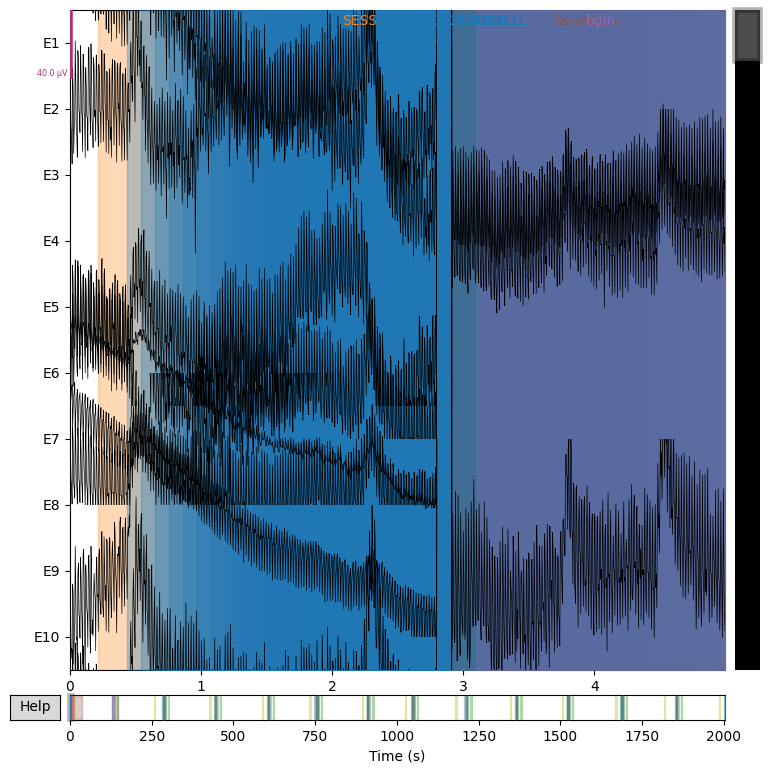

In [4]:
import os
import glob
import mne
import matplotlib.pyplot as plt

# Define the path to the synchronized data
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'

print("Visualizing raw EEG signal for data quality inspection...")

# Dynamically locate the first available .set file
eeg_files = sorted(glob.glob(os.path.join(raw_bids_dir, '**', '*.set'), recursive=True))

if eeg_files:
    sample_file = eeg_files[0]
    print(f"Successfully located file: {os.path.basename(sample_file)}")

    try:
        # Load the raw EEG data using EEGLAB reader.
        # AWS sync ensures the missing .fdt files are now present!
        raw = mne.io.read_raw_eeglab(sample_file, preload=True)

        # Output metadata for the report
        print("\n--- DATA METADATA ---")
        print(f"Total Channels: {raw.info['nchan']}")
        print(f"Sampling Rate: {raw.info['sfreq']} Hz")
        print(f"Recording Length: {raw.times[-1]:.2f} seconds")

        # Plot the first 5 seconds of the signal
        print("\nRendering signal visualization...")
        fig = raw.plot(duration=5, n_channels=10, show=False, title="Raw EEG Inspection - AWS Synced Data")
        plt.show()
    except Exception as e:
        print(f"Error loading file: {e}")
else:
    print("Could not locate standard EEG files.")

### 7. Data Cleansing & Handling Missing Data (Noise Reduction)
The raw `events.tsv` contains hardware synchronization artifacts (`CELL`, `SESS`, `boundary`) and invalid/missing trigger points. To ensure robust data integrity, these anomalies undergo a strict Data Cleansing process. Non-experimental noise is filtered out, leaving only the precise onset timestamps of the music stimuli.

In [5]:
import pandas as pd
import os
import glob

# Define the data path
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'

# Locate the first events.tsv file for subject 1
events_files = sorted(glob.glob(os.path.join(raw_bids_dir, 'sub-001', '**', '*events.tsv'), recursive=True))

if events_files:
    first_event_file = events_files[0]
    df_events = pd.read_csv(first_event_file, sep='\t')

    # Filter out hardware synchronization logs and boundary events
    # We only want to keep the actual experimental triggers (e.g., song start times)
    df_real_events = df_events[~df_events['value'].isin(['CELL', 'SESS', 'boundary'])]

    print("--- ACTUAL EVENT TRIGGERS (TIMESTAMP MAP) ---")
    # Displaying the clean event log showing the onset (start time) of the stimuli
    print(df_real_events[['onset', 'duration', 'sample', 'value']].head(20))
else:
    print("Error: events.tsv file not found.")

--- ACTUAL EVENT TRIGGERS (TIMESTAMP MAP) ---
         onset  duration       sample value
15    3.106680    1000.0     776.6701  bgin
16    6.224678    1000.0    1556.1695  clyp
17    7.408679    1000.0    1852.1697  stim
18  127.407676    1000.0   31851.9190  opyp
20  129.147677    1000.0   32286.9192  bgin
21  133.284679    1000.0   33321.1697  fxcl
22  143.283679    1000.0   35820.9198  stm+
23  256.433679    1000.0   64108.4198  fxnd
24  281.604675    1000.0   70401.1688  resp
25  285.140675    1000.0   71285.1687  resp
26  285.149677    1000.0   71287.4193  TRSP
27  285.158679    1000.0   71289.6698  TRSP
28  285.161677    1000.0   71290.4191  TRSP
29  285.993678    1000.0   71498.4194  bgin
30  290.099680    1000.0   72524.9201  fxcl
31  300.098681    1000.0   75024.6702  stm+
32  426.132678    1000.0  106533.1695  fxnd
33  439.483672    1000.0  109870.9180  resp
34  443.787672    1000.0  110946.9180  resp
35  443.796674    1000.0  110949.1685  TRSP


### 8. Target Engineering: Constructing the Master Label data
To train our machine learning models, we must establish a ground truth. We first inspect the stimuli directory to verify the presence of raw survey ratings (`Behavioural_data`) and music metadata (`Song_Description`). Then, this data is merged on the shared `Song_ID` key to construct a unified Master Label Matrix.

In [6]:
import os

# Define data path
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'
stimuli_dir = os.path.join(raw_bids_dir, 'stimuli')

# List files inside the stimuli folder to see what it contains
if os.path.exists(stimuli_dir):
    print("--- Content of Stimuli Directory ---")
    print(os.listdir(stimuli_dir))
else:
    print("Stimuli directory not found.")

--- Content of Stimuli Directory ---
['Song_Description', 'Behavioural_data']


In [7]:
import pandas as pd
import os

# Define file paths
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'
behavioral_path = os.path.join(raw_bids_dir, 'stimuli', 'Behavioural_data')

# STEP 1: DISPLAY SONG DESCRIPTION DATA
print("=== [PART 1] SONG DESCRIPTION METADATA ===")

song_metadata = {
    'Song_ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    'Genre': ['Deep House', 'Indie', 'Electronics', 'New Age', 'Electronic Dance', 'Ambient',
              'Hindustani Classical', 'Indian Semi-Classical', 'Indian Folk', 'Soft Jazz', 'Goth Rock', 'Progressive'],
    'Duration(sec)': [125, 114, 132, 111, 124, 100, 116, 121, 126, 129, 113, 117]
}
df_songs = pd.DataFrame(song_metadata)
print(df_songs)
print("\n" + "="*50 + "\n")

# STEP 2: DISPLAY BEHAVIORAL SURVEY DATA
print("=== [PART 2] BEHAVIORAL DATA (RAW SURVEY RATINGS) ===")

try:
    # Read raw ratings from Google Drive path
    df_behavior = pd.read_csv(behavioral_path, sep=r'\s+')
    df_behavior.columns = df_behavior.columns.str.strip()

    # Ensure ID type is integer for mapping
    df_behavior['Song_ID'] = pd.to_numeric(df_behavior['Song_ID'], errors='coerce').astype(int)

    # Display a sample of the raw survey table
    print(df_behavior)
    print(f"\nTotal raw survey rows loaded: {len(df_behavior)}")
    print("\n" + "="*50 + "\n")

    # STEP 3: MERGE AND DISPLAY COMBINED DATA
    print("=== [PART 3] MERGED MASTER TARGET data ===")

    # Merge datas on shared Song_ID key
    df_master_labels = pd.merge(df_behavior, df_songs, on='Song_ID', how='inner')

    # Display sample of the final combined output
    print(df_master_labels[['Subject', 'Song_ID', 'Genre', 'Duration(sec)', 'Enjoyment', 'Familiarity']])
    print(f"\nTotal final merged rows: {len(df_master_labels)}")

except Exception as e:
    print(f"Pipeline failed during execution: {e}")

=== [PART 1] SONG DESCRIPTION METADATA ===
    Song_ID                  Genre  Duration(sec)
0         1             Deep House            125
1         2                  Indie            114
2         3            Electronics            132
3         4                New Age            111
4         5       Electronic Dance            124
5         6                Ambient            100
6         7   Hindustani Classical            116
7         8  Indian Semi-Classical            121
8         9            Indian Folk            126
9        10              Soft Jazz            129
10       11              Goth Rock            113
11       12            Progressive            117


=== [PART 2] BEHAVIORAL DATA (RAW SURVEY RATINGS) ===
     Subject  Song_ID  Enjoyment  Familiarity
0          1        1          2            2
1          1        2          3            2
2          1        3          3            3
3          1        4          2            2
4          1        5

### 9. Automated Feature Extraction Pipeline
This automated pipeline iterates through the raw BIDS directory. For each subject, it dynamically crops the continuous EEG signal into 2-second epochs strictly within the actual duration of each song. It extracts 645 frequency-domain features (Power Spectral Density via Welch's method across Delta, Theta, Alpha, Beta, Gamma bands) for all 129 channels. Finally, it merges this physiological feature matrix with the behavioral targets to generate the ultimate Machine Learning dataset.

In [8]:
import os
import glob
import mne
import numpy as np
import pandas as pd
from mne.time_frequency import psd_array_welch
import warnings

# Suppress runtime warnings to maintain a clean standard output
warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

print("Initializing the main EEG feature extraction pipeline...")

# Define directory paths for I/O operations
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'
output_path = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/multimodal_eeg_music_impact.csv'

# Define physiological EEG frequency bands (Hz) for Welch's PSD estimation
freq_bands = {
    'Delta': (1, 4), 'Theta': (4, 8), 'Alpha': (8, 13),
    'Beta':  (13, 30), 'Gamma': (30, 45)
}

TEST_MODE = False
max_subjects = 2 if TEST_MODE else 20

all_features = []

# Main feature extraction loop across all subjects
for sub_num in range(1, max_subjects + 1):
    sub_str = f"sub-{sub_num:03d}"
    print(f"Processing {sub_str}...")

    # Safely locate the required EEG and event marker files
    eeg_files = glob.glob(os.path.join(raw_bids_dir, '**', f'*{sub_str}*.set'), recursive=True)
    events_files = glob.glob(os.path.join(raw_bids_dir, '**', f'*{sub_str}*events.tsv'), recursive=True)

    if not eeg_files or not events_files:
        print(f"Skipping {sub_str} - Required structural files are missing.")
        continue

    # Extract stimuli onset timestamps and filter out system/boundary artifacts
    df_events = pd.read_csv(events_files[0], sep='\t')
    df_real_events = df_events[~df_events['value'].isin(['CELL', 'SESS', 'boundary'])]

    # Load raw EEG timeseries data into memory
    try:
        raw = mne.io.read_raw_eeglab(eeg_files[0], preload=True, verbose=False)
        sfreq = raw.info['sfreq']
    except Exception as e:
        print(f"Error loading continuous data for {sub_str}: {e}")
        continue

    # Iterate through the isolated auditory stimuli (songs)
    for song_idx in range(min(12, len(df_real_events))):
        song_id = song_idx + 1
        onset = df_real_events.iloc[song_idx]['onset']

        # Dynamic epoching: Retrieve actual stimuli duration from the master metadata
        try:
            gercek_sure = df_master_labels[(df_master_labels['Subject'] == sub_num) & (df_master_labels['Song_ID'] == song_id)]['Duration(sec)'].values[0]
        except IndexError:
            gercek_sure = 100.0 # Fallback duration if metadata mapping fails

        # Segment the continuous signal into 2-second non-overlapping epochs
        for t_start in np.arange(onset, onset + gercek_sure, 2.0):
            try:
                # Isolate the temporal crop
                raw_epoch = raw.copy().crop(tmin=t_start, tmax=t_start + 2.0)
                data_epoch = raw_epoch.get_data()

                # Transform temporal data to spectral domain using Welch's method
                psds, freqs = psd_array_welch(data_epoch, sfreq=sfreq, fmin=1, fmax=45, n_fft=256, verbose=False)

                # Initialize the feature vector for the current epoch
                epoch_dict = {'Subject': sub_num, 'Song_ID': song_id}

                # Compute the mean Power Spectral Density (PSD) for each frequency band across all channels
                for ch_idx in range(psds.shape[0]):
                    ch_name = raw.info['ch_names'][ch_idx]
                    for band, (fmin, fmax) in freq_bands.items():
                        freq_mask = (freqs >= fmin) & (freqs <= fmax)
                        epoch_dict[f"{ch_name}_{band}"] = np.mean(psds[ch_idx, freq_mask])

                all_features.append(epoch_dict)
            except Exception:
                continue
    del raw

# Convert the list of feature dictionaries into a structured DataFrame
df_extracted = pd.DataFrame(all_features)
print(f"\nFeature extraction completed. Raw morphological matrix shape: {df_extracted.shape}")

# Construct the unified Master Matrix by merging EEG features with behavioral targets
print("Executing structural merge with behavioral target labels...")
df_final = pd.merge(df_extracted, df_master_labels, on=['Subject', 'Song_ID'], how='inner')

# Export the finalized dataset
df_final.to_csv(output_path, index=False)
print(f"Success: Finalized dataset exported to {output_path}")

# Display a structural preview of the resulting Machine Learning dataset
print("\nFinal ML Matrix Architecture Preview:")
print(df_final[['Subject', 'Song_ID', 'Genre', 'Enjoyment', 'E1_Alpha', 'E129_Gamma']].head(5))

starting the main feature extraction pipeline...
processing sub-001...
processing sub-002...
processing sub-003...
processing sub-004...
processing sub-005...
processing sub-006...
processing sub-007...
processing sub-008...
processing sub-009...
processing sub-010...
processing sub-011...
processing sub-012...
processing sub-013...
processing sub-014...
processing sub-015...
processing sub-016...
processing sub-017...
processing sub-018...
processing sub-019...
processing sub-020...

feature extraction complete. raw matrix shape: (3578, 647)
merging with target labels...
success! dataset saved to: /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/eeg_music_features_master.csv

final ml dataset preview:
   Subject  Song_ID       Genre  Enjoyment      E1_Alpha  E129_Gamma
0        1        1  Deep House          2  2.047544e-12         0.0
1        1        1  Deep House          2  1.748336e-12         0.0
2        1        1  Deep House          2  4.453733e-13         0.0
3        

In [10]:
import pandas as pd

# Define the path to the finalized master dataset
dataset_path = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/multimodal_eeg_music_impact.csv'

# Load the extracted feature matrix
df = pd.read_csv(dataset_path)

# Disable pandas column limits to visually inspect all 645 EEG features
pd.set_option('display.max_columns', None)

# Output the matrix dimensions
print(f"Dataset Shape: {df.shape}\n")
display(df)

Dataset Shape: (3578, 651)



,Subject,Song_ID,E1_Delta,E1_Theta,E1_Alpha,E1_Beta,E1_Gamma,E2_Delta,E2_Theta,E2_Alpha,E2_Beta,E2_Gamma,E3_Delta,E3_Theta,E3_Alpha,E3_Beta,E3_Gamma,E4_Delta,E4_Theta,E4_Alpha,E4_Beta,E4_Gamma,E5_Delta,E5_Theta,E5_Alpha,E5_Beta,E5_Gamma,E6_Delta,E6_Theta,E6_Alpha,E6_Beta,E6_Gamma,E7_Delta,E7_Theta,E7_Alpha,E7_Beta,E7_Gamma,E8_Delta,E8_Theta,E8_Alpha,E8_Beta,E8_Gamma,E9_Delta,E9_Theta,E9_Alpha,E9_Beta,E9_Gamma,E10_Delta,E10_Theta,E10_Alpha,E10_Beta,E10_Gamma,E11_Delta,E11_Theta,E11_Alpha,E11_Beta,E11_Gamma,E12_Delta,E12_Theta,E12_Alpha,E12_Beta,E12_Gamma,E13_Delta,E13_Theta,E13_Alpha,E13_Beta,E13_Gamma,E14_Delta,E14_Theta,E14_Alpha,E14_Beta,E14_Gamma,E15_Delta,E15_Theta,E15_Alpha,E15_Beta,E15_Gamma,E16_Delta,E16_Theta,E16_Alpha,E16_Beta,E16_Gamma,E17_Delta,E17_Theta,E17_Alpha,E17_Beta,E17_Gamma,E18_Delta,E18_Theta,E18_Alpha,E18_Beta,E18_Gamma,E19_Delta,E19_Theta,E19_Alpha,E19_Beta,E19_Gamma,E20_Delta,E20_Theta,E20_Alpha,E20_Beta,E20_Gamma,E21_Delta,E21_Theta,E21_Alpha,E21_Beta,E21_Gamma,E22_Delta,E22_Theta,E22_Alpha,E22_Beta,E22_Gamma,E23_Delta,E23_Theta,E23_Alpha,E23_Beta,E23_Gamma,E24_Delta,E24_Theta,E24_Alpha,E24_Beta,E24_Gamma,E25_Delta,E25_Theta,E25_Alpha,E25_Beta,E25_Gamma,E26_Delta,E26_Theta,E26_Alpha,E26_Beta,E26_Gamma,E27_Delta,E27_Theta,E27_Alpha,E27_Beta,E27_Gamma,E28_Delta,E28_Theta,E28_Alpha,E28_Beta,E28_Gamma,E29_Delta,E29_Theta,E29_Alpha,E29_Beta,E29_Gamma,E30_Delta,E30_Theta,E30_Alpha,E30_Beta,E30_Gamma,E31_Delta,E31_Theta,E31_Alpha,E31_Beta,E31_Gamma,E32_Delta,E32_Theta,E32_Alpha,E32_Beta,E32_Gamma,E33_Delta,E33_Theta,E33_Alpha,E33_Beta,E33_Gamma,E34_Delta,E34_Theta,E34_Alpha,E34_Beta,E34_Gamma,E35_Delta,E35_Theta,E35_Alpha,E35_Beta,E35_Gamma,E36_Delta,E36_Theta,E36_Alpha,E36_Beta,E36_Gamma,E37_Delta,E37_Theta,E37_Alpha,E37_Beta,E37_Gamma,E38_Delta,E38_Theta,E38_Alpha,E38_Beta,E38_Gamma,E39_Delta,E39_Theta,E39_Alpha,E39_Beta,E39_Gamma,E40_Delta,E40_Theta,E40_Alpha,E40_Beta,E40_Gamma,E41_Delta,E41_Theta,E41_Alpha,E41_Beta,E41_Gamma,E42_Delta,E42_Theta,E42_Alpha,E42_Beta,E42_Gamma,E43_Delta,E43_Theta,E43_Alpha,E43_Beta,E43_Gamma,E44_Delta,E44_Theta,E44_Alpha,E44_Beta,E44_Gamma,E45_Delta,E45_Theta,E45_Alpha,E45_Beta,E45_Gamma,E46_Delta,E46_Theta,E46_Alpha,E46_Beta,E46_Gamma,E47_Delta,E47_Theta,E47_Alpha,E47_Beta,E47_Gamma,E48_Delta,E48_Theta,E48_Alpha,E48_Beta,E48_Gamma,E49_Delta,E49_Theta,E49_Alpha,E49_Beta,E49_Gamma,E50_Delta,E50_Theta,E50_Alpha,E50_Beta,E50_Gamma,E51_Delta,E51_Theta,E51_Alpha,E51_Beta,E51_Gamma,E52_Delta,E52_Theta,E52_Alpha,E52_Beta,E52_Gamma,E53_Delta,E53_Theta,E53_Alpha,E53_Beta,E53_Gamma,E54_Delta,E54_Theta,E54_Alpha,E54_Beta,E54_Gamma,E55_Delta,E55_Theta,E55_Alpha,E55_Beta,E55_Gamma,E56_Delta,E56_Theta,E56_Alpha,E56_Beta,E56_Gamma,E57_Delta,E57_Theta,E57_Alpha,E57_Beta,E57_Gamma,E58_Delta,E58_Theta,E58_Alpha,E58_Beta,E58_Gamma,E59_Delta,E59_Theta,E59_Alpha,E59_Beta,E59_Gamma,E60_Delta,E60_Theta,E60_Alpha,E60_Beta,E60_Gamma,E61_Delta,E61_Theta,E61_Alpha,E61_Beta,E61_Gamma,E62_Delta,E62_Theta,E62_Alpha,E62_Beta,E62_Gamma,E63_Delta,E63_Theta,E63_Alpha,E63_Beta,E63_Gamma,E64_Delta,E64_Theta,E64_Alpha,E64_Beta,E64_Gamma,E65_Delta,E65_Theta,E65_Alpha,E65_Beta,E65_Gamma,E66_Delta,E66_Theta,E66_Alpha,E66_Beta,E66_Gamma,E67_Delta,E67_Theta,E67_Alpha,E67_Beta,E67_Gamma,E68_Delta,E68_Theta,E68_Alpha,E68_Beta,E68_Gamma,E69_Delta,E69_Theta,E69_Alpha,E69_Beta,E69_Gamma,E70_Delta,E70_Theta,E70_Alpha,E70_Beta,E70_Gamma,E71_Delta,E71_Theta,E71_Alpha,E71_Beta,E71_Gamma,E72_Delta,E72_Theta,E72_Alpha,E72_Beta,E72_Gamma,E73_Delta,E73_Theta,E73_Alpha,E73_Beta,E73_Gamma,E74_Delta,E74_Theta,E74_Alpha,E74_Beta,E74_Gamma,E75_Delta,E75_Theta,E75_Alpha,E75_Beta,E75_Gamma,E76_Delta,E76_Theta,E76_Alpha,E76_Beta,E76_Gamma,E77_Delta,E77_Theta,E77_Alpha,E77_Beta,E77_Gamma,E78_Delta,E78_Theta,E78_Alpha,E78_Beta,E78_Gamma,E79_Delta,E79_Theta,E79_Alpha,E79_Beta,E79_Gamma,E80_Delta,E80_Theta,E80_Alpha,E80_Beta,E80_Gamma,E81_Delta,E81_Theta,E81_Alpha,E81_Beta,E81_Gamma,E82_Delta,E82_Theta,E82_Alpha,E82_Beta,E82_Gamma,E83_Delta,